# An example of PyAge to calibrate LPM models on CFCs data

All files necessary for the code to work

In [1]:
%matplotlib inline

In [2]:
import copy
import sys
import os
import math

import convolutions.concentrations as co
from convolutions import concentrations_time as ct
import convolutions.concentrations as concentrations
import global_parameters as gp
import LPM.LPM_generate as LPM_generate

import calibration.calibration_exploration
import calibration.calibration_common as calbas
import calibration.calibration_simplex as csimp
import calibration.calibration_Metropolis_Hastings as cMH

from sites.ploemeur.postprocessing import appli_ploemeur_tools

## Parameters

In [3]:
# ---------------- CONCENTRATIONS DATA ------------------
# Concentration data
# file = "ploemeur_F22_2007"
# date = 2007
file = "ploemeur_F09_2010"
date = 2010
verbose = True

## Output Directory

In [4]:
# ---------------- OUTPUT DIRECTORY ----------------------
directory_results = gp.results_directory(gp.ROOT_DIRECTORY_RESULTS,"test_cases")
directory_results = gp.results_directory(directory_results,file)

## Display Options

Selection of the different types of outputs

In [5]:
# ---- DISPLAY OPTIONS + ROOT OUTPUT DIRECTORY ------------
display = gp.display_options()
display.text = True
display.figure = True
display.figure_close = False
display.figure_save = True
display.directory = directory_results 

## Concentration data

Defined by the directory and file names. These should be modified to match the location of the data in hard-drive directories

<span style="color:red">*Directory should be entered here if needed; default is sites/ploemeur/data under ROOT_DIRECTORY*</span>

In [6]:
# Data Loading
filename=os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data", file)
if verbose:
    print("Data file location: ", filename)
concentration_sampled=co.Concentrations(file_load=True, file_name = filename)
# Adds some percentage of uncertainty to the data
# concentration_sampled.error_affect_from_value(error_concentrations)
concentration_sampled.display(display)
# Copy results to root directory
concentration_sampled.cv.to_csv(os.path.join(display.directory,"concentrations.txt"),sep='\t')

Data file location:  C:\DATA\codes-github-public\trac-2-age\python\sources\tests_data\ploemeur\ploemeur_F09_2010
  element  concentration  error  unit         date
0   cfc11     234.375117   10.4  pptv  2010.975342
1   cfc12     476.387635   22.5  pptv  2010.975342
2  cfc113      68.551112    5.1  pptv  2010.975342


## LPM model

Defined by te LPM type and the directory where the characteristics of the LPM are given
Parameters are acceptable boundaries, initial values for calibration and Metropolis Hastings parameters 

In [7]:
lpm_type = "dirac_double"
directory_lpm = os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data", "LPM_data")
directory_lpm = os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data", "LPM_data")
print("parameters for the calibration are in directory:\n\t", directory_lpm)

parameters for the calibration are in directory:
	 C:\DATA\codes-github-public\trac-2-age\python\sources\tests_data\ploemeur\LPM_data


## Reachable Concentrations

With a systematic sampling of the parameter space, displays the concentrations that can be reached with the chosen LPM

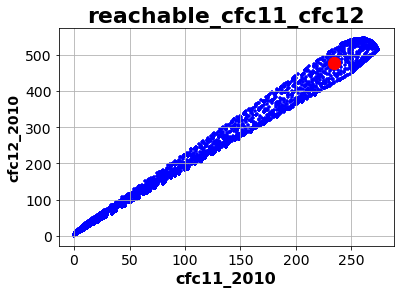

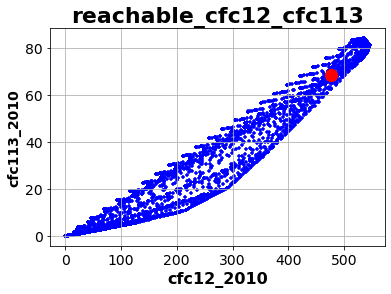

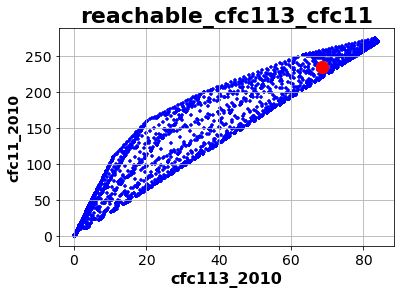

In [8]:
resolution=10000
# ---------------- REACHABLE CONCENTRATIONS -------------
directory_cr = gp.results_directory(display.directory,"reachable_concentrations")
display_cr=copy.deepcopy(display)
display_cr.directory_results=gp.results_directory(display.directory,"reachable_concentrations")

cr = calibration_exploration.CalibrationReachConc(lpm_type, concentration_sampled.names(), 
                                                  date = concentration_sampled.cv["date"], 
                                                  nmodels=resolution, display_options=display_cr)
cr.compute_concentrations()
cr.output()
cr.display_concentrations_with_data(concentration_sampled)

## Calibration
### Parameters
Parameters for the Forward error propagation and Metropolis Hastings Methods 

In [9]:
# ---------------- CALIBRATION PARAMETERS ----------------
calstrat=[None]*2

# ---------------- FORWARD UNCERTAINTY QUANTIFICATION -----------------------------
calstrat[0] = csimp.CalibrationSimplex("forward_uncertainty_quantification",
                                            init_multiples_n=5,fuq_n=50)

# ---------------- METROPOLIS HASTINGS --------------------
# Method and Parameters  
calstrat[1] = cMH.CalibrationMetropolisHastings(nstep=25000,prior=False,likelyhood=True,
                                                     monitor=True,display_traj=True)
# calstrat[1].MH_step.define_by_prop(0.005)
calstrat[1].MH_step.define_by_value()

### Calibration per se

In [10]:
lpm_results=[None]*2
# ---------------- CALIBRATION -------------
for i in range(len(calstrat)):
    # Outputs of Interpration
    directory_calibration = gp.results_directory(display.directory,calstrat[i].method)
    # Calibration
    calib_basis=calbas.CalibrationCommon(concentration_sampled,lpm_type,directory_results=directory_calibration,directory_lpm=directory_lpm)
    calstrat[i].update_calibbasis(calib_basis)
    lpm_results[i]=calstrat[i].perform()
    # Stores/Writes Results
    calstrat[i].write_calibrated_lpm(lpm_results[i])

### Displays Results as graphics 
Distribution of parameters 
Distribution of concentrations
Relations between parameters (when number of parameters is larger than 2) 

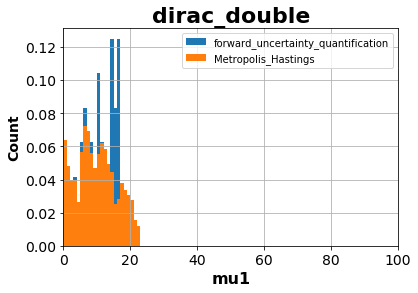

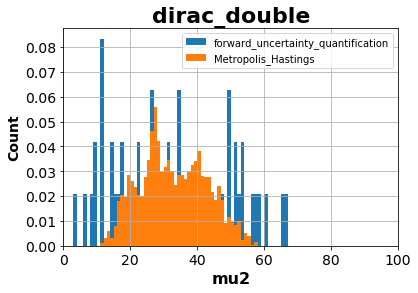

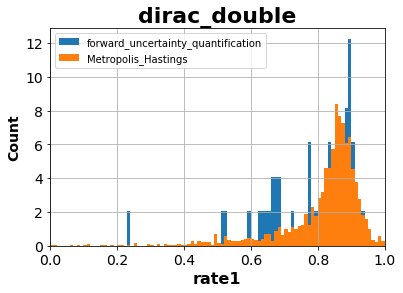

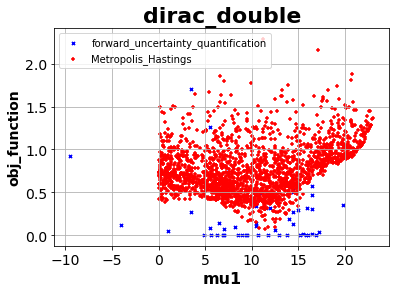

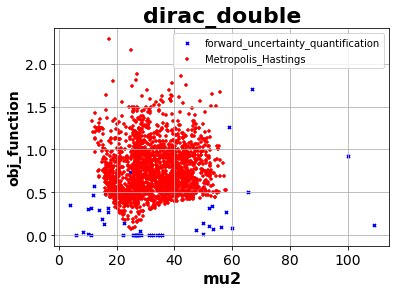

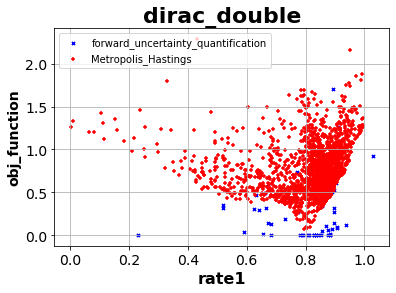

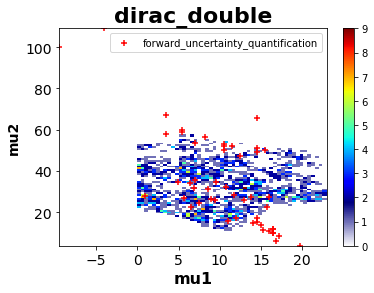

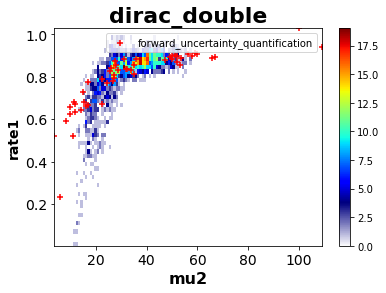

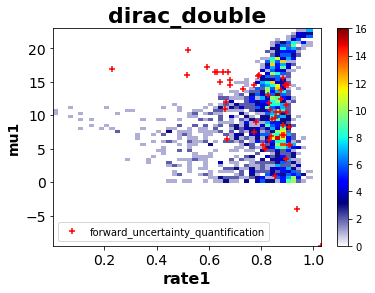

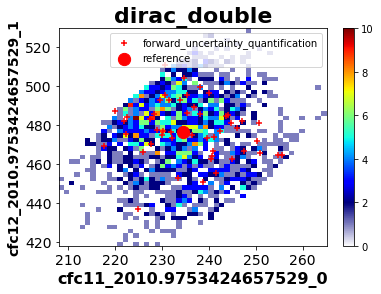

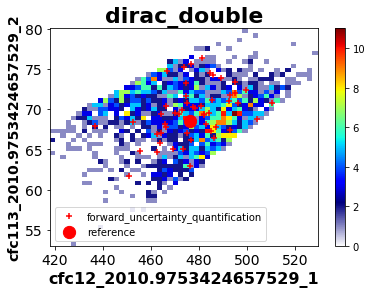

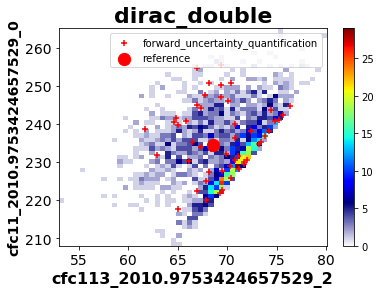

In [11]:
# ---------------- SYNTHETIC FIGURES --------------------
lpm_results[0].display_parameters_dist(self_method=calstrat[0].method,lpm_reference=None,
                                               lpm_2nd=lpm_results[1],
                                               lpm_2nd_method=calstrat[1].method,
                                               directory=display.directory)
lpm_results[0].display_concentrations_dist(self_method=calstrat[0].method,
                                                   concentrations_reference=concentration_sampled,
                                                   lpm_2nd=lpm_results[1],
                                                   lpm_2nd_method=calstrat[1].method,
                                                   directory=display.directory)

### Objective function representation
Crosscuts when parameter number is larger than 3 

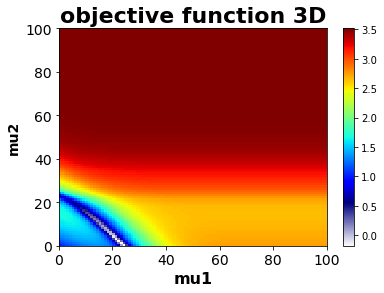

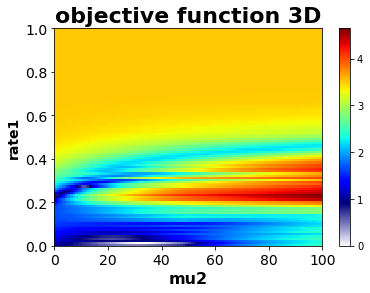

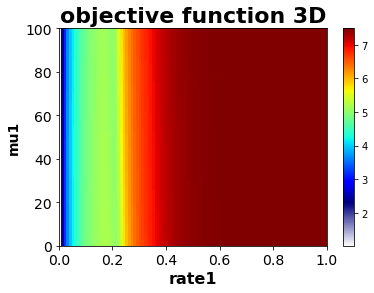

In [12]:
# ------- OBJECTIVE FUNCTION -------------------------------
resoluiton = 50000

calstrat[1].build_objective_function(display,resolution=resolution)

### Resulting concentration chronicles of tracers and models 
Models are represented by lines of different colors

C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010 	 Metropolis_Hastings
problem in set_interp of LPM Dirac
C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010 	 forward_uncertainty_quantification


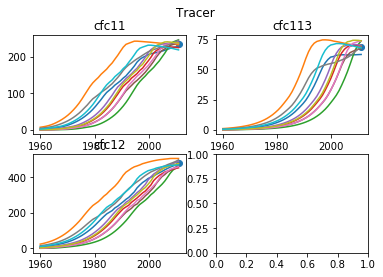

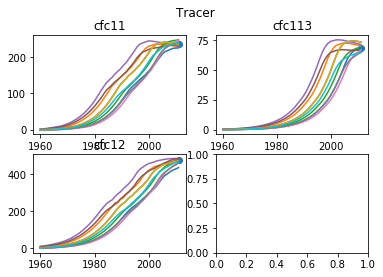

In [13]:
# ------------- CONCENTRATION OUTPUTS ----------------------
lpm=LPM_generate.LPM_generate(lpm_type,directory_lpm=gp.directory_lpm_data)
ct.display_concentration_times([display.directory],lpm,display)

All results (figures and data) are avialable in the following directory

In [14]:
print(display.directory)

C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010
